## **Name: Chirag Chaudhari**
## **Roll no: 24102A2003**
## **Branch: CMPN-A**
## **Problem Statement no: 7**
## **Title: Customer Segmentation and Predictive Analytics**



In [1]:
required_packages <- c(
  "readxl", "dplyr", "tidyr", "ggplot2", "scales",
  "cluster", "factoextra", "randomForest", "e1071",
  "pROC", "caret", "plotly", "htmlwidgets"
)

installed <- rownames(installed.packages())
to_install <- setdiff(required_packages, installed)

if (length(to_install) > 0) {
  install.packages(to_install, repos = "https://cloud.r-project.org")
}

library(readxl)
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)
library(cluster)
library(factoextra)
library(randomForest)
library(e1071)
library(pROC)
library(caret)
library(plotly)
library(htmlwidgets)

set.seed(42)

cat("All required packages are loaded successfully.\n")


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘future’, ‘globals’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘shape’, ‘future.apply’, ‘progressr’, ‘SQUAREM’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘diagram’, ‘lava’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘showtextdb’, ‘corrplot’, ‘prodlim’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘irlba’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘showtext’, ‘sysfonts’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘lazyeval’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘ggrepel’, ‘proxy’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘recipes’, ‘reshape2’, ‘crosstalk’



Attaching pack

All required packages are loaded successfully.


In [2]:
data_path <- "/content/Online Retail.xlsx"

if (!file.exists(data_path)) {
  cat("Online Retail.xlsx was not found in /content.\n")
  cat("Please upload it using the Colab Files panel, then run this cell again.\n")
} else {
  retail <- read_excel(data_path)

  cat("Dataset loaded successfully.\n")
  cat("Rows:", nrow(retail), "\n")
  cat("Columns:", ncol(retail), "\n\n")

  print(head(retail))
}


Dataset loaded successfully.
Rows: 541909 
Columns: 8 

# A tibble: 6 × 8
  InvoiceNo StockCode Description         Quantity InvoiceDate         UnitPrice
  <chr>     <chr>     <chr>                  <dbl> <dttm>                  <dbl>
1 536365    85123A    WHITE HANGING HEAR…        6 2010-12-01 08:26:00      2.55
2 536365    71053     WHITE METAL LANTERN        6 2010-12-01 08:26:00      3.39
3 536365    84406B    CREAM CUPID HEARTS…        8 2010-12-01 08:26:00      2.75
4 536365    84029G    KNITTED UNION FLAG…        6 2010-12-01 08:26:00      3.39
5 536365    84029E    RED WOOLLY HOTTIE …        6 2010-12-01 08:26:00      3.39
6 536365    22752     SET 7 BABUSHKA NES…        2 2010-12-01 08:26:00      7.65
# ℹ 2 more variables: CustomerID <dbl>, Country <chr>


In [3]:
if (exists("retail")) {
  cat("Column names:\n")
  print(names(retail))

  cat("\nData structure:\n")
  str(retail)

  cat("\nMissing values:\n")
  print(sort(colSums(is.na(retail)), decreasing = TRUE))

  cat("\nSummary:\n")
  print(summary(retail))
}


Column names:
[1] "InvoiceNo"   "StockCode"   "Description" "Quantity"    "InvoiceDate"
[6] "UnitPrice"   "CustomerID"  "Country"    

Data structure:
tibble [541,909 × 8] (S3: tbl_df/tbl/data.frame)
 $ InvoiceNo  : chr [1:541909] "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr [1:541909] "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr [1:541909] "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : num [1:541909] 6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: POSIXct[1:541909], format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 $ UnitPrice  : num [1:541909] 2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : num [1:541909] 17850 17850 17850 17850 17850 ...
 $ Country    : chr [1:541909] "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...

Missing values:
 CustomerID Description   InvoiceNo   StockCode    Quantity InvoiceDate 
    

##  Data Preprocessing


In [4]:
retail_clean <- retail %>%
  mutate(
    InvoiceNo = as.character(InvoiceNo),
    CustomerID = as.character(CustomerID),
    InvoiceDate = as.POSIXct(InvoiceDate),
    Quantity = as.numeric(Quantity),
    UnitPrice = as.numeric(UnitPrice)
  ) %>%
  filter(
    !is.na(CustomerID),
    !grepl("^C", InvoiceNo, ignore.case = TRUE),
    Quantity > 0,
    UnitPrice > 0,
    !is.na(InvoiceDate)
  ) %>%
  mutate(
    TotalAmount = Quantity * UnitPrice
  )

cat("Rows after preprocessing:", nrow(retail_clean), "\n")
cat("Customers:", n_distinct(retail_clean$CustomerID), "\n")

head(retail_clean)


Rows after preprocessing: 397884 
Customers: 4338 


InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<chr>,<chr>,<dbl>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom,15.30


## Outlier Treatment

In [5]:
# Winsorize transaction values at the 1st and 99th percentiles.
lower_limit <- quantile(retail_clean$TotalAmount, 0.01, na.rm = TRUE)
upper_limit <- quantile(retail_clean$TotalAmount, 0.99, na.rm = TRUE)

retail_clean <- retail_clean %>%
  mutate(
    TotalAmount_Capped = pmin(
      pmax(TotalAmount, lower_limit),
      upper_limit
    )
  )

cat("Original minimum:", min(retail_clean$TotalAmount), "\n")
cat("Original maximum:", max(retail_clean$TotalAmount), "\n")
cat("1% limit:", lower_limit, "\n")
cat("99% limit:", upper_limit, "\n")


Original minimum: 0.001 
Original maximum: 168469.6 
1% limit: 0.55 
99% limit: 202.5 


## Customer-Level Feature Engineering — RFM

In [6]:
reference_date <- max(retail_clean$InvoiceDate, na.rm = TRUE) + 86400

customer_data <- retail_clean %>%
  group_by(CustomerID) %>%
  summarise(
    LastPurchaseDate = max(InvoiceDate, na.rm = TRUE),
    Frequency = n_distinct(InvoiceNo),
    Monetary = sum(TotalAmount_Capped, na.rm = TRUE),
    TotalQuantity = sum(Quantity, na.rm = TRUE),
    AverageTransactionValue = mean(TotalAmount_Capped, na.rm = TRUE),
    ProductCount = n_distinct(StockCode),
    Country = first(Country),
    .groups = "drop"
  ) %>%
  mutate(
    Recency = as.numeric(difftime(
      reference_date,
      LastPurchaseDate,
      units = "days"
    )),
    PurchaseFrequency = Frequency / (Recency + 1) * 30
  )

feature_cols <- c(
  "Recency",
  "Frequency",
  "Monetary",
  "AverageTransactionValue",
  "TotalQuantity",
  "ProductCount",
  "PurchaseFrequency"
)

cat("Number of customers:", nrow(customer_data), "\n")
print(head(customer_data))


Number of customers: 4338 
# A tibble: 6 × 10
  CustomerID LastPurchaseDate    Frequency Monetary TotalQuantity
  <chr>      <dttm>                  <int>    <dbl>         <dbl>
1 12346      2011-01-18 10:01:00         1     202.         74215
2 12347      2011-12-07 15:52:00         7    4263.          2458
3 12348      2011-09-25 13:13:00         4    1760.          2341
4 12349      2011-11-21 09:51:00         1    1660.           631
5 12350      2011-02-02 16:01:00         1     334.           197
6 12352      2011-11-03 14:37:00         8    2254.           536
# ℹ 5 more variables: AverageTransactionValue <dbl>, ProductCount <int>,
#   Country <chr>, Recency <dbl>, PurchaseFrequency <dbl>


## Customer Feature Distribution

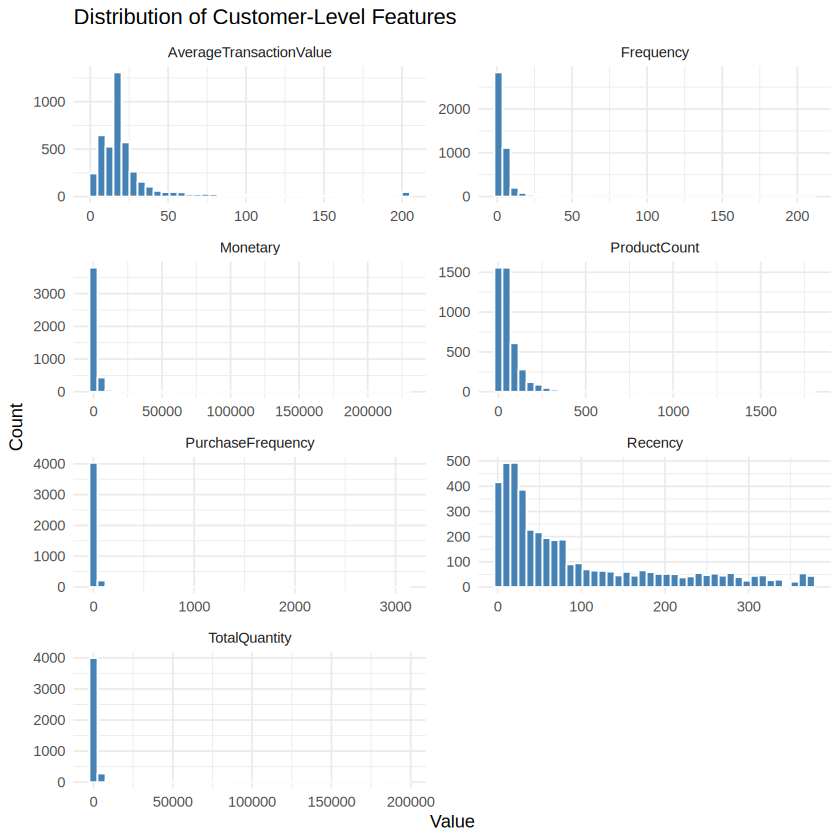

In [7]:
customer_long <- customer_data %>%
  select(all_of(feature_cols)) %>%
  pivot_longer(
    cols = everything(),
    names_to = "Feature",
    values_to = "Value"
  )

ggplot(customer_long, aes(x = Value)) +
  geom_histogram(bins = 40, fill = "steelblue", color = "white") +
  facet_wrap(~ Feature, scales = "free", ncol = 2) +
  theme_minimal() +
  labs(
    title = "Distribution of Customer-Level Features",
    x = "Value",
    y = "Count"
  )


## Log Transformation and Standardization

In [8]:
# log1p handles zero values safely and reduces right skew.
X_raw <- customer_data %>%
  select(all_of(feature_cols))

X_log <- log1p(X_raw)

# Standardization
X_scaled <- scale(X_log)

cat("Scaled feature matrix dimensions:",
    nrow(X_scaled), "x", ncol(X_scaled), "\n")

head(X_scaled)


Scaled feature matrix dimensions: 4338 x 7 


Recency,Frequency,Monetary,AverageTransactionValue,TotalQuantity,ProductCount,PurchaseFrequency
1.4789643,-0.9551042,-1.0150763,3.1194312,3.8162133,-2.5260846,-0.9449965
-1.9142605,1.0743013,1.4627347,0.3226003,1.3293320,0.9657698,2.0615975
0.3723584,0.3862599,0.7423852,1.4582536,1.2937504,-0.3676958,-0.2922667
-0.6538931,-0.9551042,0.6949150,0.2852321,0.3376956,0.6650118,-0.3129165
1.4424469,-0.9551042,-0.6081249,0.1025721,-0.5094249,-0.5843192,-0.9418551
-0.1691716,1.2467247,0.9440725,0.4802808,0.2188037,0.4796743,0.5140484


## Elbow Method

Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”


   K       WSS
1  2 17588.671
2  3 14218.850
3  4 12425.627
4  5 11144.535
5  6 10098.164
6  7  9268.145
7  8  8513.659
8  9  7990.371
9 10  7502.936


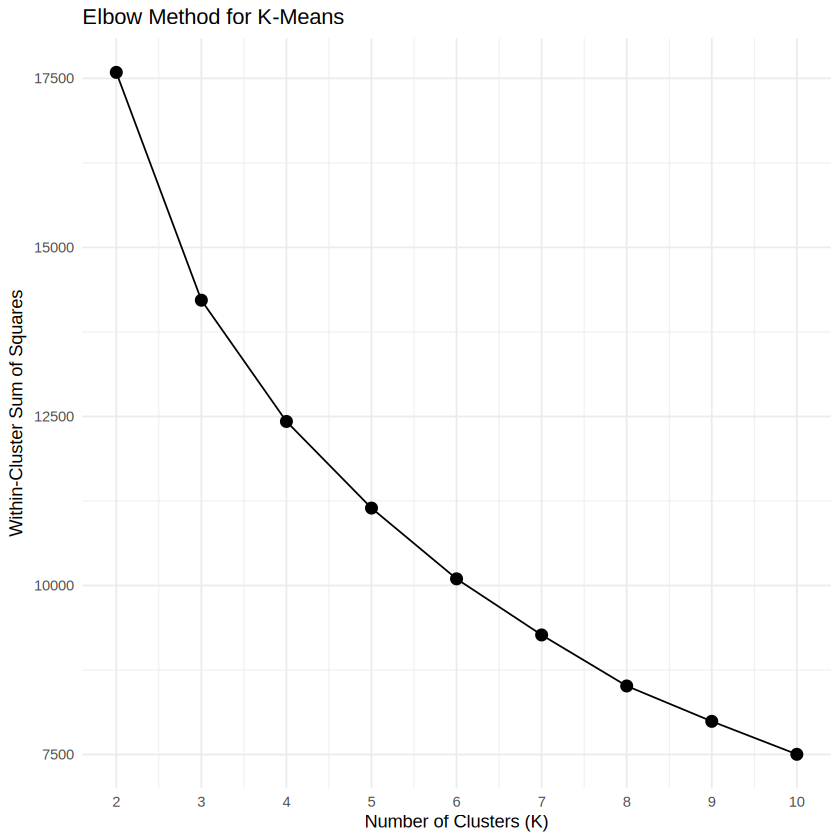

In [9]:
k_values <- 2:10
wss <- numeric(length(k_values))

for (i in seq_along(k_values)) {
  km <- kmeans(
    X_scaled,
    centers = k_values[i],
    nstart = 20
  )
  wss[i] <- km$tot.withinss
}

elbow_df <- data.frame(
  K = k_values,
  WSS = wss
)

print(elbow_df)

ggplot(elbow_df, aes(x = K, y = WSS)) +
  geom_line() +
  geom_point(size = 3) +
  scale_x_continuous(breaks = k_values) +
  theme_minimal() +
  labs(
    title = "Elbow Method for K-Means",
    x = "Number of Clusters (K)",
    y = "Within-Cluster Sum of Squares"
  )


## Silhouette Score for Candidate K Values

Warning message:
“did not converge in 10 iterations”


   K Silhouette
1  2  0.3697014
2  3  0.2622941
3  4  0.2161630
4  5  0.2181308
5  6  0.2324788
6  7  0.2087835
7  8  0.2205047
8  9  0.2262809
9 10  0.2140858

Selected K based on highest silhouette score: 2 


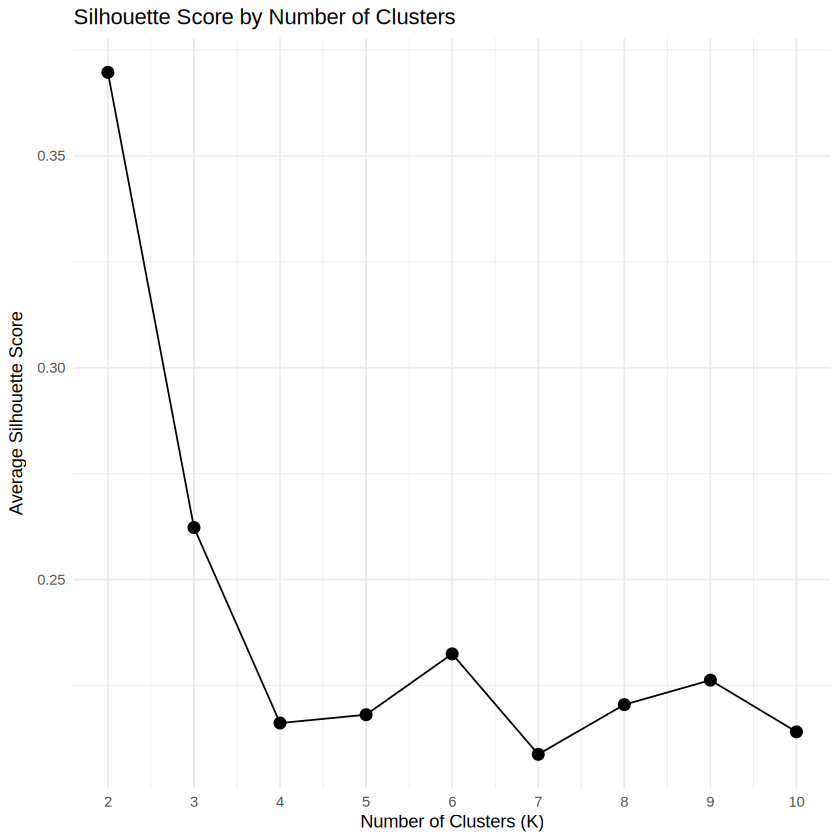

In [10]:
silhouette_scores <- numeric(length(k_values))

for (i in seq_along(k_values)) {
  km <- kmeans(
    X_scaled,
    centers = k_values[i],
    nstart = 20
  )

  sil <- silhouette(km$cluster, dist(X_scaled))
  silhouette_scores[i] <- mean(sil[, "sil_width"])
}

silhouette_df <- data.frame(
  K = k_values,
  Silhouette = silhouette_scores
)

print(silhouette_df)

ggplot(silhouette_df, aes(x = K, y = Silhouette)) +
  geom_line() +
  geom_point(size = 3) +
  scale_x_continuous(breaks = k_values) +
  theme_minimal() +
  labs(
    title = "Silhouette Score by Number of Clusters",
    x = "Number of Clusters (K)",
    y = "Average Silhouette Score"
  )

optimal_k <- silhouette_df$K[
  which.max(silhouette_df$Silhouette)
]

cat("\nSelected K based on highest silhouette score:", optimal_k, "\n")


## K-Means Customer Segmentation

In [11]:
kmeans_model <- kmeans(
  X_scaled,
  centers = optimal_k,
  nstart = 50
)

customer_data$KMeans_Cluster <- factor(kmeans_model$cluster)

kmeans_sil <- silhouette(
  kmeans_model$cluster,
  dist(X_scaled)
)

kmeans_silhouette_score <- mean(kmeans_sil[, "sil_width"])

cat("K-Means Silhouette Score:",
    round(kmeans_silhouette_score, 4), "\n\n")

cat("Customers per cluster:\n")
print(table(customer_data$KMeans_Cluster))


K-Means Silhouette Score: 0.3697 

Customers per cluster:

   1    2 
1625 2713 


## Hierarchical Clustering and Dendrogram

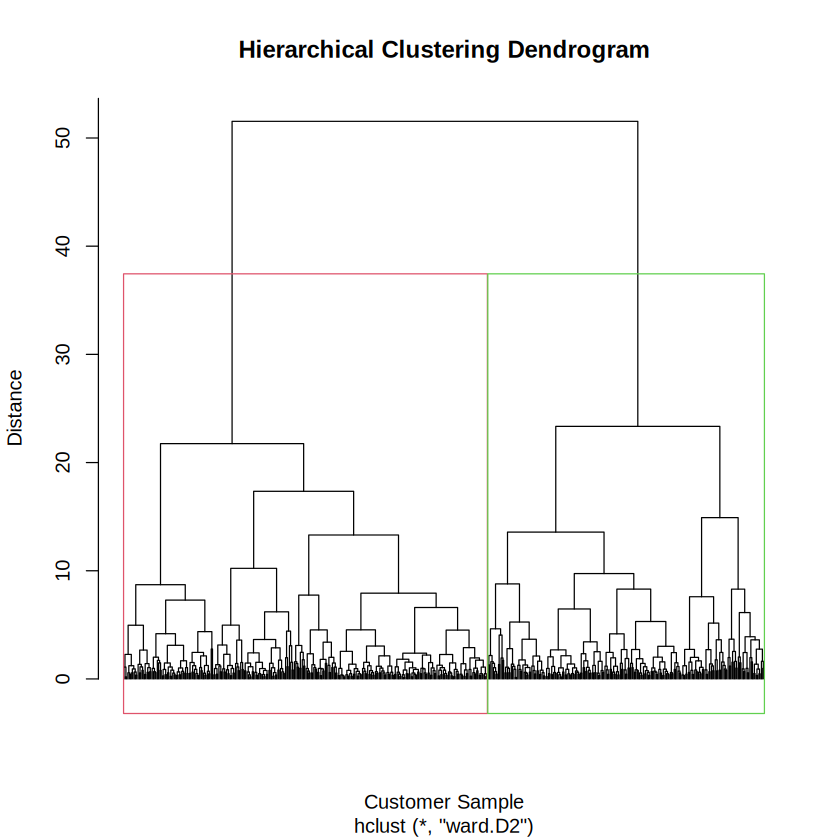

In [12]:
# A full dendrogram with thousands of customers is unreadable.
# Therefore, use a reproducible sample of up to 500 customers.

sample_size <- min(500, nrow(X_scaled))
sample_indices <- sample(seq_len(nrow(X_scaled)), sample_size)

X_hier <- X_scaled[sample_indices, , drop = FALSE]

hier_dist <- dist(X_hier)
hier_tree <- hclust(hier_dist, method = "ward.D2")

plot(
  hier_tree,
  labels = FALSE,
  hang = -1,
  main = "Hierarchical Clustering Dendrogram",
  xlab = "Customer Sample",
  ylab = "Distance"
)

rect.hclust(
  hier_tree,
  k = optimal_k,
  border = 2:(optimal_k + 1)
)


##  Hierarchical Clustering

In [13]:
hierarchical_model <- hclust(
  dist(X_scaled),
  method = "ward.D2"
)

hier_labels <- cutree(
  hierarchical_model,
  k = optimal_k
)

hier_sil <- silhouette(
  hier_labels,
  dist(X_scaled)
)

hier_silhouette_score <- mean(hier_sil[, "sil_width"])

customer_data$Hierarchical_Cluster <- factor(hier_labels)

cat("Hierarchical Clustering Silhouette Score:",
    round(hier_silhouette_score, 4), "\n\n")

cat("Customers per hierarchical cluster:\n")
print(table(customer_data$Hierarchical_Cluster))


Hierarchical Clustering Silhouette Score: 0.3366 

Customers per hierarchical cluster:

   1    2 
2355 1983 


## Clustering Method Comparison

                   Method Silhouette_Score
1                 K-Means        0.3697014
2 Hierarchical Clustering        0.3365537


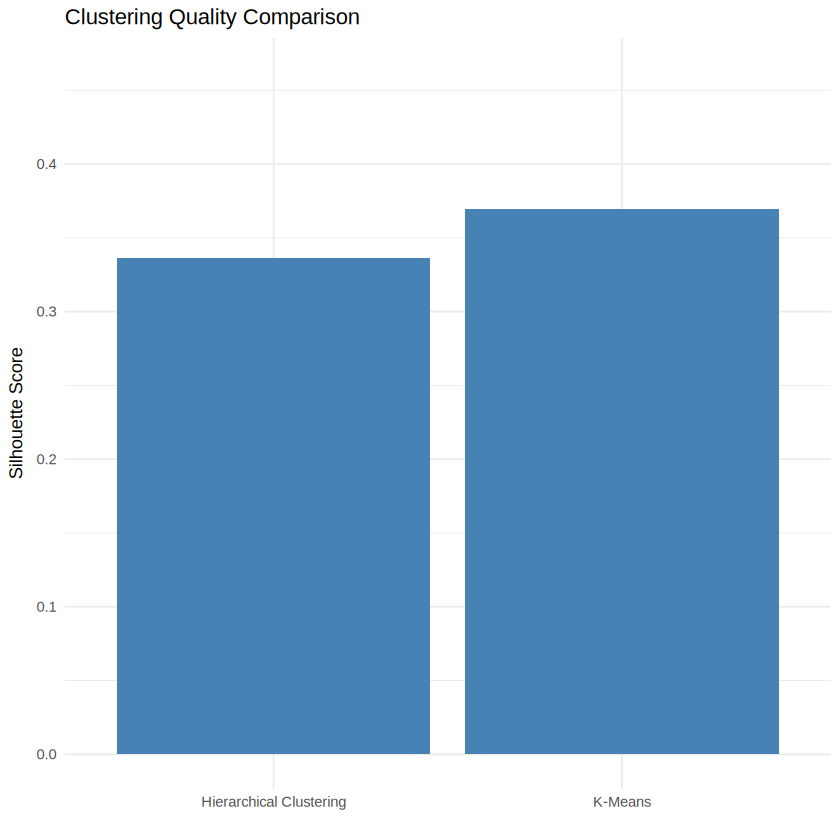

In [14]:
comparison <- data.frame(
  Method = c("K-Means", "Hierarchical Clustering"),
  Silhouette_Score = c(
    kmeans_silhouette_score,
    hier_silhouette_score
  )
)

print(comparison)

ggplot(comparison, aes(
  x = Method,
  y = Silhouette_Score
)) +
  geom_col(fill = "steelblue") +
  ylim(0, max(comparison$Silhouette_Score) * 1.25) +
  theme_minimal() +
  labs(
    title = "Clustering Quality Comparison",
    x = "",
    y = "Silhouette Score"
  )


## PCA — 2D Visualization

Variance explained by PC1: 63.12 %
Variance explained by PC2: 18.87 %
Variance explained by first 3 PCs: 12.01 %


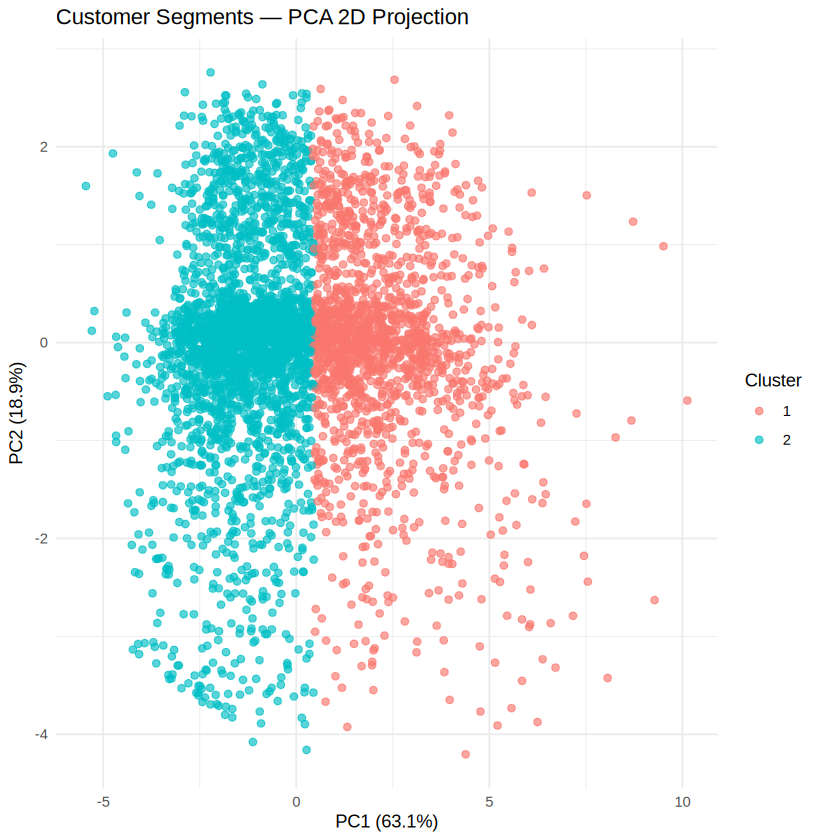

In [15]:
pca_model <- prcomp(
  X_scaled,
  center = FALSE,
  scale. = FALSE
)

pca_data <- as.data.frame(
  pca_model$x[, 1:2]
)

names(pca_data) <- c("PC1", "PC2")

customer_data$PC1 <- pca_data$PC1
customer_data$PC2 <- pca_data$PC2

explained_variance <- summary(pca_model)$importance[2, 1:3] * 100

cat("Variance explained by PC1:",
    round(explained_variance[1], 2), "%\n")
cat("Variance explained by PC2:",
    round(explained_variance[2], 2), "%\n")
cat("Variance explained by first 3 PCs:",
    round(explained_variance[3], 2), "%\n")

ggplot(
  customer_data,
  aes(
    x = PC1,
    y = PC2,
    color = KMeans_Cluster
  )
) +
  geom_point(alpha = 0.65, size = 1.8) +
  theme_minimal() +
  labs(
    title = "Customer Segments — PCA 2D Projection",
    x = paste0("PC1 (", round(explained_variance[1], 1), "%)"),
    y = paste0("PC2 (", round(explained_variance[2], 1), "%)"),
    color = "Cluster"
  )


## Cluster Profiling

In [16]:
cluster_profile <- customer_data %>%
  group_by(KMeans_Cluster) %>%
  summarise(
    Customers = n(),
    across(
      all_of(feature_cols),
      list(
        Mean = ~mean(.x, na.rm = TRUE),
        Median = ~median(.x, na.rm = TRUE)
      )
    ),
    .groups = "drop"
  )

print(cluster_profile)


# A tibble: 2 × 16
  KMeans_Cluster Customers Recency_Mean Recency_Median Frequency_Mean
  <fct>              <int>        <dbl>          <dbl>          <dbl>
1 1                   1625         27.1           17.0           8.53
2 2                   2713        133.            93.1           1.72
# ℹ 11 more variables: Frequency_Median <int>, Monetary_Mean <dbl>,
#   Monetary_Median <dbl>, AverageTransactionValue_Mean <dbl>,
#   AverageTransactionValue_Median <dbl>, TotalQuantity_Mean <dbl>,
#   TotalQuantity_Median <dbl>, ProductCount_Mean <dbl>,
#   ProductCount_Median <int>, PurchaseFrequency_Mean <dbl>,
#   PurchaseFrequency_Median <dbl>


Warning message:
“There was 1 warning in `summarise()`.
ℹ In argument: `across(all_of(feature_cols), mean, na.rm = TRUE)`.
ℹ In group 1: `KMeans_Cluster = 1`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))”


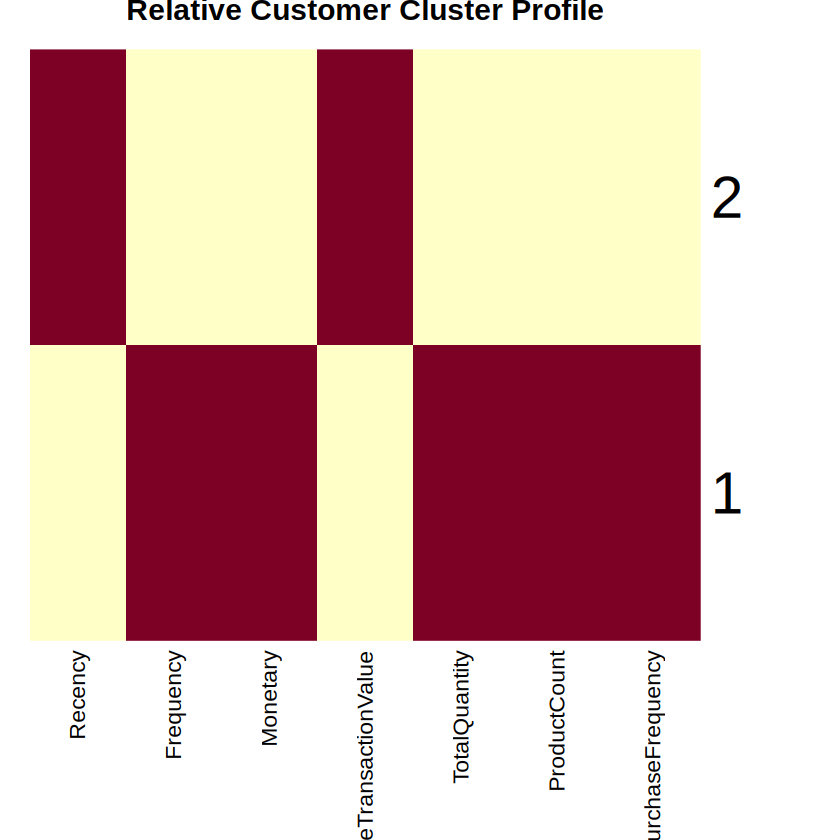

In [17]:
# Relative profile heatmap using standardized cluster means.
profile_means <- customer_data %>%
  group_by(KMeans_Cluster) %>%
  summarise(
    across(all_of(feature_cols), mean, na.rm = TRUE),
    .groups = "drop"
  )

profile_matrix <- as.matrix(profile_means[, feature_cols])
rownames(profile_matrix) <- profile_means$KMeans_Cluster

profile_scaled <- scale(log1p(profile_matrix))

heatmap(
  profile_scaled,
  Rowv = NA,
  Colv = NA,
  scale = "none",
  main = "Relative Customer Cluster Profile",
  margins = c(10, 6)
)


## Identify the High-Value Customer Segment



In [18]:
monetary_by_cluster <- customer_data %>%
  group_by(KMeans_Cluster) %>%
  summarise(
    Average_Monetary = mean(Monetary, na.rm = TRUE),
    Customers = n(),
    .groups = "drop"
  ) %>%
  arrange(desc(Average_Monetary))

print(monetary_by_cluster)

high_value_cluster <- as.character(
  monetary_by_cluster$KMeans_Cluster[1]
)

customer_data$High_Value <- ifelse(
  as.character(customer_data$KMeans_Cluster) == high_value_cluster,
  1,
  0
)

cat("\nHigh-value cluster:", high_value_cluster, "\n")
cat(
  "High-value customers:",
  sum(customer_data$High_Value),
  "\n"
)
cat(
  "High-value percentage:",
  round(mean(customer_data$High_Value) * 100, 2),
  "%\n"
)


# A tibble: 2 × 3
  KMeans_Cluster Average_Monetary Customers
  <fct>                     <dbl>     <int>
1 1                         3846.      1625
2 2                          476.      2713

High-value cluster: 1 
High-value customers: 1625 
High-value percentage: 37.46 %


## Prepare Data for Supervised Learning

In [19]:
# Do NOT include KMeans_Cluster as a predictor.
# Otherwise, the model would receive the variable used to create the target.

X_model_raw <- customer_data %>%
  select(all_of(feature_cols))

X_model_log <- log1p(X_model_raw)

model_scaler <- preProcess(
  X_model_log,
  method = c("center", "scale")
)

X_model <- predict(model_scaler, X_model_log)

y_model <- factor(
  customer_data$High_Value,
  levels = c(0, 1),
  labels = c("Not_High_Value", "High_Value")
)

# Stratified train/test split
train_index <- createDataPartition(
  y_model,
  p = 0.80,
  list = FALSE
)

X_train <- X_model[train_index, ]
X_test <- X_model[-train_index, ]

y_train <- y_model[train_index]
y_test <- y_model[-train_index]

cat("Training observations:", nrow(X_train), "\n")
cat("Testing observations:", nrow(X_test), "\n\n")

cat("Training class distribution:\n")
print(prop.table(table(y_train)))


Training observations: 3471 
Testing observations: 867 

Training class distribution:
y_train
Not_High_Value     High_Value 
     0.6254682      0.3745318 


## Random Forest

In [20]:
rf_model <- randomForest(
  x = X_train,
  y = y_train,
  ntree = 300,
  importance = TRUE
)

rf_pred <- predict(rf_model, X_test)
rf_prob <- predict(
  rf_model,
  X_test,
  type = "prob"
)[, "High_Value"]

cat("Random Forest model created successfully.\n\n")
print(rf_model)


Random Forest model created successfully.


Call:
 randomForest(x = X_train, y = y_train, ntree = 300, importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 300
No. of variables tried at each split: 2

        OOB estimate of  error rate: 1.38%
Confusion matrix:
               Not_High_Value High_Value class.error
Not_High_Value           2149         22  0.01013358
High_Value                 26       1274  0.02000000


## SVM

In [21]:
svm_model <- svm(
  x = X_train,
  y = y_train,
  kernel = "radial",
  probability = TRUE,
  class.weights = c(
    "Not_High_Value" = 1,
    "High_Value" = 1
  )
)

svm_pred <- predict(
  svm_model,
  X_test,
  probability = TRUE
)

svm_prob_matrix <- attr(svm_pred, "probabilities")
svm_prob <- svm_prob_matrix[, "High_Value"]

cat("SVM model created successfully.\n")


SVM model created successfully.


## Model Evaluation

In [23]:
calculate_metrics <- function(
    actual,
    predicted,
    probability,
    model_name
) {
  cm <- confusionMatrix(
    predicted,
    actual,
    positive = "High_Value"
  )

  roc_obj <- roc(
    response = actual,
    predictor = probability,
    levels = c("Not_High_Value", "High_Value"),
    direction = "<",
    quiet = TRUE
  )

  data.frame(
    Model = model_name,
    Accuracy = unname(cm$overall["Accuracy"]),
    Precision = unname(cm$byClass["Precision"]),
    Recall = unname(cm$byClass["Recall"]),
    F1_Score = unname(cm$byClass["F1"]),
    ROC_AUC = as.numeric(auc(roc_obj))
  )
}

rf_metrics <- calculate_metrics(
  y_test,
  rf_pred,
  rf_prob,
  "Random Forest"
)

svm_metrics <- calculate_metrics(
  y_test,
  svm_pred,
  svm_prob,
  "SVM"
)

model_results <- bind_rows(
  rf_metrics,
  svm_metrics
)

print(
  model_results %>%
    mutate(
      Accuracy = round(Accuracy, 4),
      Precision = round(Precision, 4),
      Recall = round(Recall, 4),
      F1_Score = round(F1_Score, 4),
      ROC_AUC = round(ROC_AUC, 4)
    )
)


          Model Accuracy Precision Recall F1_Score ROC_AUC
1 Random Forest   0.9908    0.9969 0.9785   0.9876  0.9997
2           SVM   0.9988    1.0000 0.9969   0.9985  1.0000


## Confusion Matrix

In [24]:
cat("Random Forest Confusion Matrix:\n")
print(
  confusionMatrix(
    rf_pred,
    y_test,
    positive = "High_Value"
  )
)

cat("\nSVM Confusion Matrix:\n")
print(
  confusionMatrix(
    svm_pred,
    y_test,
    positive = "High_Value"
  )
)


Random Forest Confusion Matrix:
Confusion Matrix and Statistics

                Reference
Prediction       Not_High_Value High_Value
  Not_High_Value            541          7
  High_Value                  1        318
                                         
               Accuracy : 0.9908         
                 95% CI : (0.9819, 0.996)
    No Information Rate : 0.6251         
    P-Value [Acc > NIR] : <2e-16         
                                         
                  Kappa : 0.9802         
                                         
 Mcnemar's Test P-Value : 0.0771         
                                         
            Sensitivity : 0.9785         
            Specificity : 0.9982         
         Pos Pred Value : 0.9969         
         Neg Pred Value : 0.9872         
             Prevalence : 0.3749         
         Detection Rate : 0.3668         
   Detection Prevalence : 0.3679         
      Balanced Accuracy : 0.9883         
                        

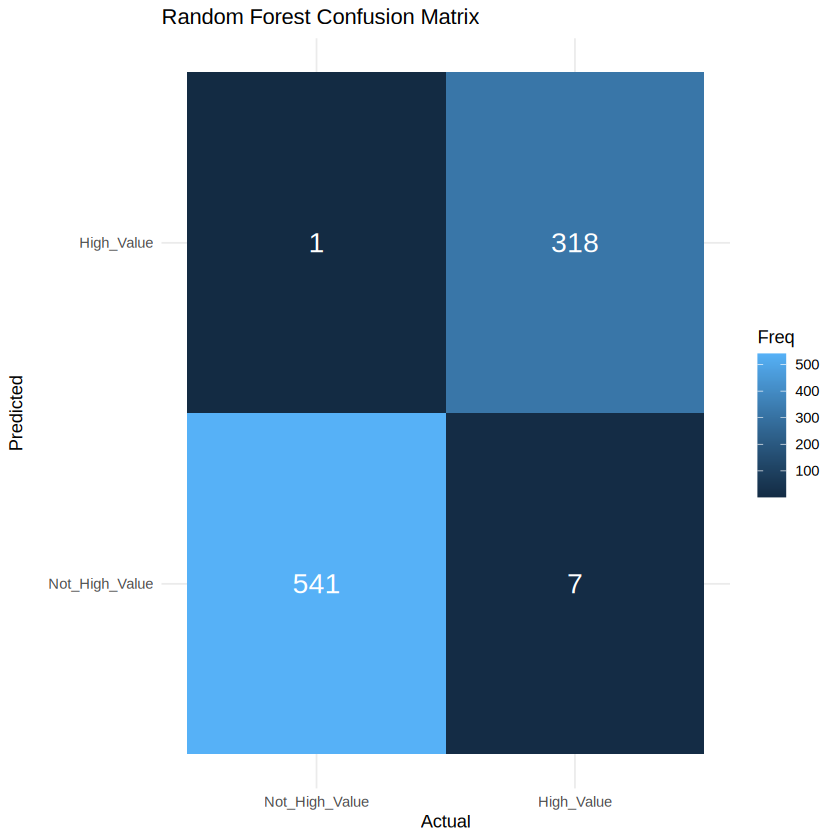

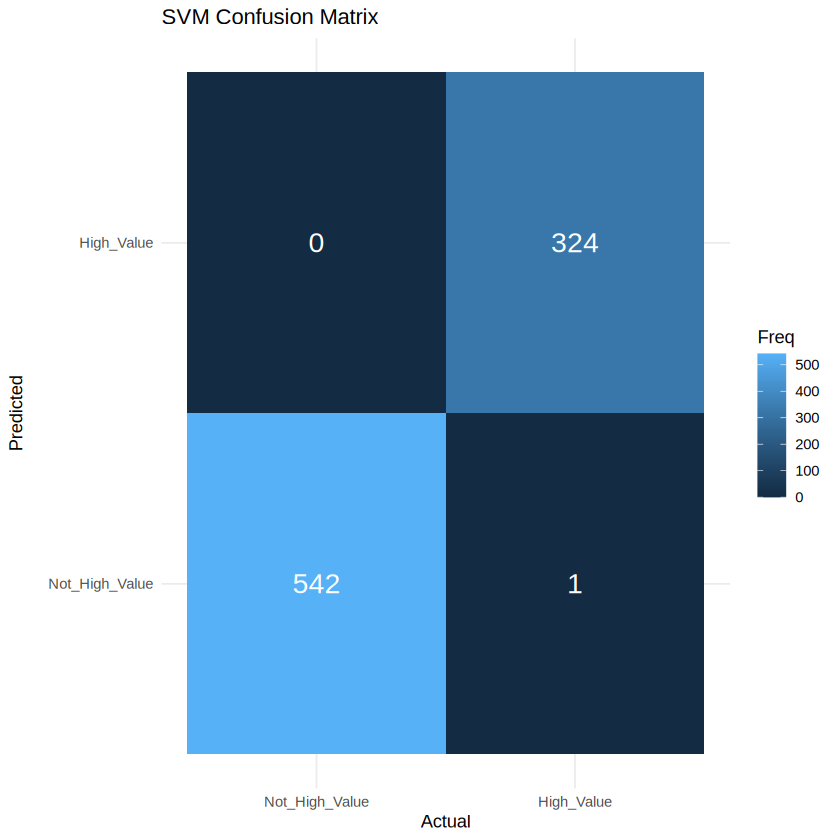

In [25]:
cm_rf <- as.data.frame(
  table(
    Actual = y_test,
    Predicted = rf_pred
  )
)

cm_svm <- as.data.frame(
  table(
    Actual = y_test,
    Predicted = svm_pred
  )
)

ggplot(cm_rf, aes(x = Actual, y = Predicted, fill = Freq)) +
  geom_tile() +
  geom_text(aes(label = Freq), color = "white", size = 6) +
  theme_minimal() +
  labs(
    title = "Random Forest Confusion Matrix",
    x = "Actual",
    y = "Predicted"
  )

ggplot(cm_svm, aes(x = Actual, y = Predicted, fill = Freq)) +
  geom_tile() +
  geom_text(aes(label = Freq), color = "white", size = 6) +
  theme_minimal() +
  labs(
    title = "SVM Confusion Matrix",
    x = "Actual",
    y = "Predicted"
  )


## Model Performance Comparison

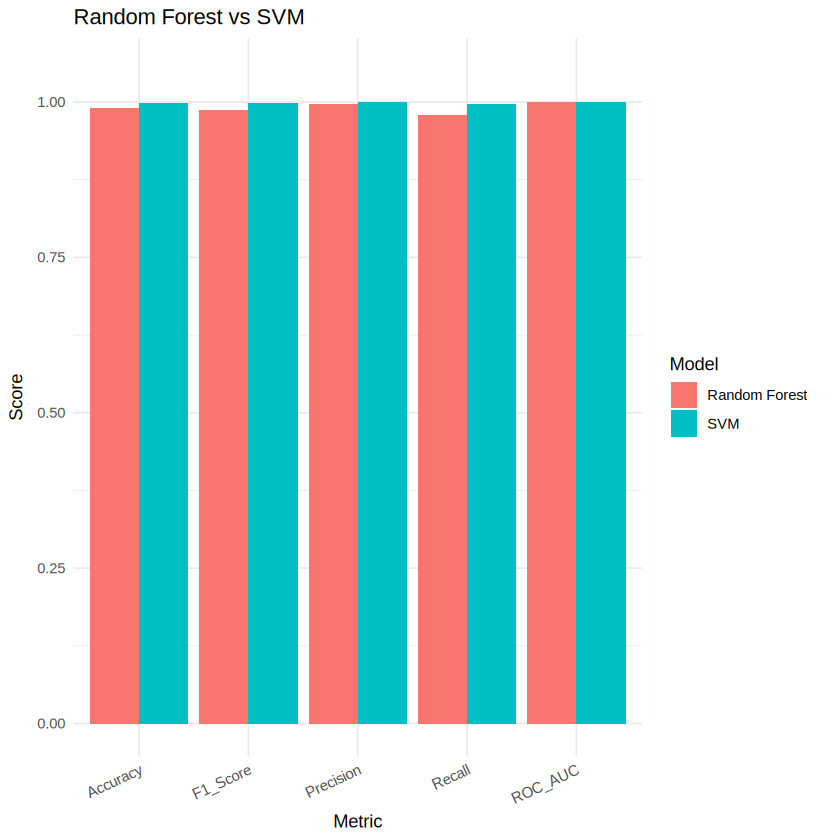

In [26]:
results_long <- model_results %>%
  pivot_longer(
    cols = c(
      Accuracy,
      Precision,
      Recall,
      F1_Score,
      ROC_AUC
    ),
    names_to = "Metric",
    values_to = "Score"
  )

ggplot(
  results_long,
  aes(
    x = Metric,
    y = Score,
    fill = Model
  )
) +
  geom_col(position = "dodge") +
  ylim(0, 1.05) +
  theme_minimal() +
  labs(
    title = "Random Forest vs SVM",
    x = "Metric",
    y = "Score"
  ) +
  theme(axis.text.x = element_text(angle = 25, hjust = 1))


## ROC Curves

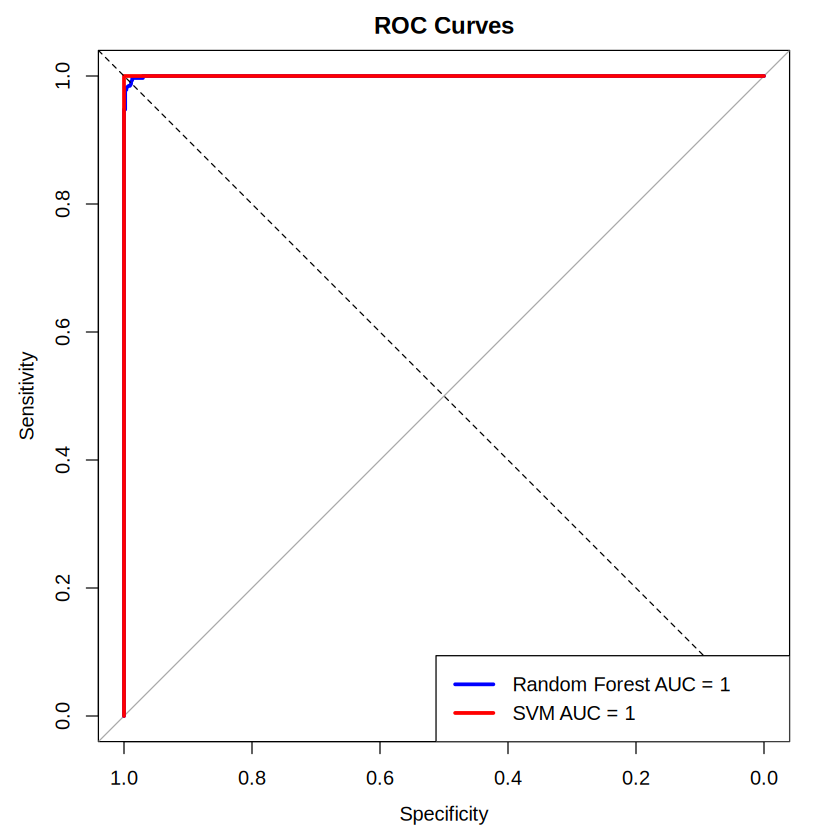

In [27]:
rf_roc <- roc(
  y_test,
  rf_prob,
  levels = c("Not_High_Value", "High_Value"),
  direction = "<",
  quiet = TRUE
)

svm_roc <- roc(
  y_test,
  svm_prob,
  levels = c("Not_High_Value", "High_Value"),
  direction = "<",
  quiet = TRUE
)

plot(
  rf_roc,
  col = "blue",
  lwd = 3,
  main = "ROC Curves"
)

lines(
  svm_roc,
  col = "red",
  lwd = 3
)

abline(
  a = 0,
  b = 1,
  lty = 2
)

legend(
  "bottomright",
  legend = c(
    paste0("Random Forest AUC = ", round(auc(rf_roc), 3)),
    paste0("SVM AUC = ", round(auc(svm_roc), 3))
  ),
  col = c("blue", "red"),
  lwd = 3
)


## Random Forest Feature Importance

                  Feature MeanDecreaseAccuracy MeanDecreaseGini
1       PurchaseFrequency             43.03791         446.6085
2                Monetary             29.99282         330.0838
3               Frequency             21.55849         317.5681
4           TotalQuantity             27.12039         242.4074
5            ProductCount             31.82197         152.6060
6                 Recency             21.62701         104.1250
7 AverageTransactionValue             21.07320          32.2399


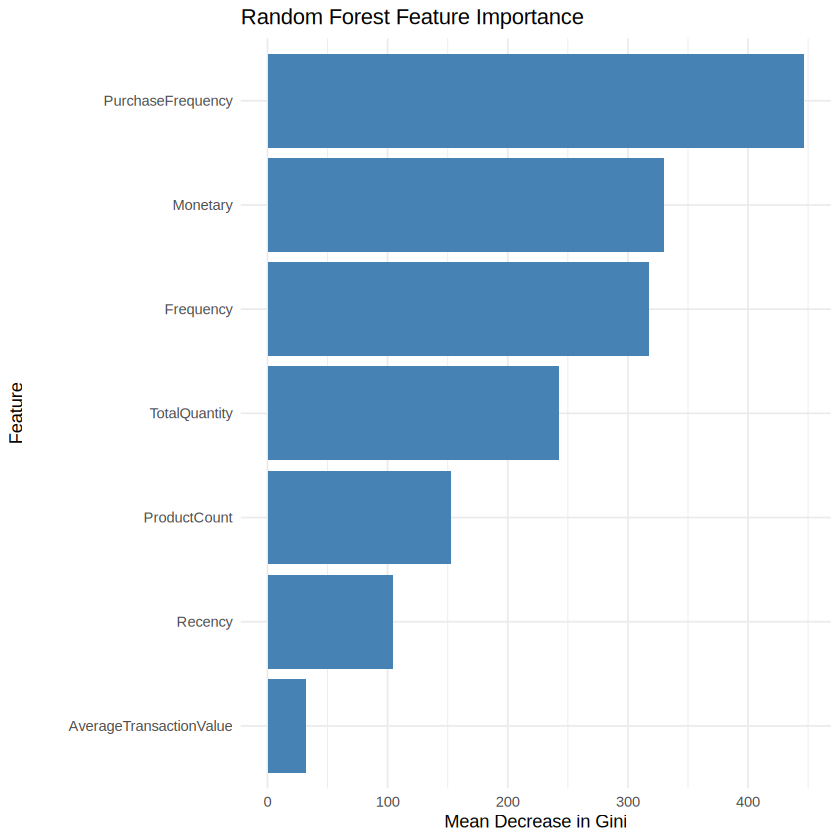

In [28]:
importance_values <- importance(rf_model)

importance_df <- data.frame(
  Feature = rownames(importance_values),
  MeanDecreaseAccuracy = importance_values[, "MeanDecreaseAccuracy"],
  MeanDecreaseGini = importance_values[, "MeanDecreaseGini"],
  row.names = NULL
) %>%
  arrange(desc(MeanDecreaseGini))

print(importance_df)

ggplot(
  importance_df,
  aes(
    x = reorder(Feature, MeanDecreaseGini),
    y = MeanDecreaseGini
  )
) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  theme_minimal() +
  labs(
    title = "Random Forest Feature Importance",
    x = "Feature",
    y = "Mean Decrease in Gini"
  )


## Interactive 3D PCA Visualization

In [29]:
pca3_model <- prcomp(
  X_scaled,
  center = FALSE,
  scale. = FALSE
)

pca3_data <- as.data.frame(
  pca3_model$x[, 1:3]
)

names(pca3_data) <- c(
  "PC1_3D",
  "PC2_3D",
  "PC3_3D"
)

customer_data$PC1_3D <- pca3_data$PC1_3D
customer_data$PC2_3D <- pca3_data$PC2_3D
customer_data$PC3_3D <- pca3_data$PC3_3D

interactive_plot <- plot_ly(
  customer_data,
  x = ~PC1_3D,
  y = ~PC2_3D,
  z = ~PC3_3D,
  color = ~KMeans_Cluster,
  type = "scatter3d",
  mode = "markers",
  marker = list(size = 4),
  text = ~paste(
    "Customer:", CustomerID,
    "<br>Recency:", round(Recency, 1),
    "<br>Frequency:", Frequency,
    "<br>Monetary:", round(Monetary, 2)
  ),
  hoverinfo = "text"
) %>%
  layout(
    title = "Interactive 3D Customer Clusters",
    scene = list(
      xaxis = list(title = "PC1"),
      yaxis = list(title = "PC2"),
      zaxis = list(title = "PC3")
    )
  )

interactive_plot


HTML widgets cannot be represented in plain text (need html)

## Segment-Wise Customer Profiles and Marketing Recommendations

In [30]:
cluster_means <- customer_data %>%
  group_by(KMeans_Cluster) %>%
  summarise(
    Customers = n(),
    Avg_Recency = mean(Recency, na.rm = TRUE),
    Avg_Frequency = mean(Frequency, na.rm = TRUE),
    Avg_Monetary = mean(Monetary, na.rm = TRUE),
    Avg_Transaction_Value = mean(
      AverageTransactionValue,
      na.rm = TRUE
    ),
    Avg_Quantity = mean(TotalQuantity, na.rm = TRUE),
    Avg_Product_Count = mean(ProductCount, na.rm = TRUE),
    .groups = "drop"
  )

recommendation_df <- cluster_means %>%
  mutate(
    Marketing_Recommendation = case_when(
      as.character(KMeans_Cluster) == high_value_cluster ~
        "High-value: loyalty rewards, premium offers and personalized campaigns.",
      Avg_Recency > median(Avg_Recency) &
        Avg_Frequency < median(Avg_Frequency) ~
        "At-risk: re-engagement campaigns, reminders and limited-time offers.",
      Avg_Frequency > median(Avg_Frequency) ~
        "Frequent buyers: cross-selling, bundles and loyalty benefits.",
      Avg_Monetary > median(Avg_Monetary) ~
        "Higher-spend opportunity: personalized recommendations and premium offers.",
      TRUE ~
        "Regular customers: targeted promotions, cross-selling and retention campaigns."
    )
  )

print(recommendation_df)


# A tibble: 2 × 9
  KMeans_Cluster Customers Avg_Recency Avg_Frequency Avg_Monetary
  <fct>              <int>       <dbl>         <dbl>        <dbl>
1 1                   1625        27.1          8.53        3846.
2 2                   2713       133.           1.72         476.
# ℹ 4 more variables: Avg_Transaction_Value <dbl>, Avg_Quantity <dbl>,
#   Avg_Product_Count <dbl>, Marketing_Recommendation <chr>


In [33]:
cat("============================================================\n")
cat("FINAL EXPERIMENT SUMMARY\n")
cat("============================================================\n")

cat("Original transaction rows:", nrow(retail), "\n")
cat("Cleaned transaction rows:", nrow(retail_clean), "\n")
cat("Customers analyzed:", nrow(customer_data), "\n")
cat("Selected number of clusters:", optimal_k, "\n")

cat(
  "K-Means Silhouette Score:",
  round(kmeans_silhouette_score, 4),
  "\n"
)

cat(
  "Hierarchical Silhouette Score:",
  round(hier_silhouette_score, 4),
  "\n"
)

cat("High-value cluster:", high_value_cluster, "\n")

cat(
  "High-value customers:",
  sum(customer_data$High_Value),
  "\n\n"
)

# ------------------------------------------------------------
# MODEL PERFORMANCE
# ------------------------------------------------------------

cat("MODEL PERFORMANCE:\n")

model_results_display <- model_results %>%
  mutate(
    Accuracy = round(Accuracy, 4),
    Precision = round(Precision, 4),
    Recall = round(Recall, 4),
    F1_Score = round(F1_Score, 4),
    ROC_AUC = round(ROC_AUC, 4)
  )

print(model_results_display)

# ------------------------------------------------------------
# FEATURE IMPORTANCE
# ------------------------------------------------------------

cat("\nFEATURE IMPORTANCE:\n")

importance_display <- importance_df %>%
  mutate(
    MeanDecreaseAccuracy = round(MeanDecreaseAccuracy, 4),
    MeanDecreaseGini = round(MeanDecreaseGini, 4)
  )

print(importance_display)

# ------------------------------------------------------------
# MARKETING RECOMMENDATIONS
# ------------------------------------------------------------

cat("\nMARKETING RECOMMENDATIONS:\n")
print(recommendation_df)

FINAL EXPERIMENT SUMMARY
Original transaction rows: 541909 
Cleaned transaction rows: 397884 
Customers analyzed: 4338 
Selected number of clusters: 2 
K-Means Silhouette Score: 0.3697 
Hierarchical Silhouette Score: 0.3366 
High-value cluster: 1 
High-value customers: 1625 

MODEL PERFORMANCE:
          Model Accuracy Precision Recall F1_Score ROC_AUC
1 Random Forest   0.9908    0.9969 0.9785   0.9876  0.9997
2           SVM   0.9988    1.0000 0.9969   0.9985  1.0000

FEATURE IMPORTANCE:
                  Feature MeanDecreaseAccuracy MeanDecreaseGini
1       PurchaseFrequency              43.0379         446.6085
2                Monetary              29.9928         330.0838
3               Frequency              21.5585         317.5681
4           TotalQuantity              27.1204         242.4074
5            ProductCount              31.8220         152.6060
6                 Recency              21.6270         104.1250
7 AverageTransactionValue              21.0732          32

# Conclusion

This experiment implements an end-to-end customer analytics solution in R using the UCI Online Retail dataset.

The transaction data is cleaned and converted into customer-level RFM and behavioral features. K-Means clustering is applied for customer segmentation, with the Elbow Method and Silhouette Score used to determine and validate the number of clusters. Hierarchical clustering and a dendrogram provide a second clustering perspective.

PCA is used to visualize the customer segments in two dimensions, while cluster profiling helps explain the purchasing characteristics of each segment. The cluster with the highest average Monetary value is defined as the high-value segment.

Random Forest and SVM models are then trained to predict high-value customers. Their performance is compared using Accuracy, Precision, Recall, F1-Score, ROC-AUC and Confusion Matrix. Random Forest feature importance identifies the customer features that contribute most to prediction.

Finally, segment-specific marketing recommendations are generated to demonstrate how the analysis can support business decision-making.
